# **Uber Trip Duration Prediction Using Machine Learning**

## 1. Introduction

Regression is a supervised machine learning technique used to predict continuous numerical values. In transportation applications, regression models can help estimate trip durations using information such as trip distance, pickup location, passenger count, and pickup time.

This case study uses an Uber trip dataset to develop and compare five regression algorithms for predicting trip duration.

## 2. Problem Statement

The objective is to predict the duration of an Uber trip in minutes using relevant trip characteristics available at pickup time.

## 3. Objectives

- Load and explore the Uber trip dataset.
- Calculate trip duration using pickup and drop-off timestamps.
- Clean and preprocess the dataset.
- Train five machine learning regression algorithms.
- Evaluate models using MAE, MSE, RMSE, and R² score.
- Compare model performance using graphs and actual-versus-predicted plots.
- Identify the best-performing model based on the evaluation results.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


## 4. Dataset Description

The dataset contains Uber trip records with 19 columns and 100,000 rows.

The available variables include vendor identification, pickup and drop-off timestamps, passenger count, trip distance, pickup and drop-off coordinates, rate code, payment type, fare amount, tip amount, tolls, and other charges.

The target variable, `trip_duration_minutes`, will be calculated by subtracting the pickup timestamp from the drop-off timestamp. The resulting continuous numerical value makes this a regression problem.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving uber_data.csv to uber_data.csv


In [ ]:
import io

file_name = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Number of rows: 100000
Number of columns: 19


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,-73.976746,40.765152,1,N,-74.004265,40.746128,1,9.0,0.5,0.5,2.05,0.00,0.3,12.35
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,-73.983482,40.767925,1,N,-74.005943,40.733166,1,11.0,0.5,0.5,3.05,0.00,0.3,15.35
2,2,2016-03-01 00:00:00,2016-03-01 00:31:06,2,19.98,-73.782021,40.644810,1,N,-73.974541,40.675770,1,54.5,0.5,0.5,8.00,0.00,0.3,63.80
3,2,2016-03-01 00:00:00,2016-03-01 00:00:00,3,10.78,-73.863419,40.769814,1,N,-73.969650,40.757767,1,31.5,0.0,0.5,3.78,5.54,0.3,41.62
4,2,2016-03-01 00:00:00,2016-03-01 00:00:00,5,30.43,-73.971741,40.792183,3,N,-74.177170,40.695053,1,98.0,0.0,0.0,0.00,15.50,0.3,113.80


## 5. Regression Approach

In this experiment, trip duration is treated as a continuous target variable measured in minutes. The five regression algorithms will learn relationships between the available input features and trip duration.

Model performance will be evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). Lower MAE, MSE, and RMSE values generally indicate smaller prediction errors, while a higher R² score indicates a better fit to the observed target values.

# 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure, quality, and characteristics of the Uber trip dataset before building regression models.

This section examines the dataset dimensions, column names, data types, missing values, duplicate records, and statistical summaries. Visualizations are used to understand trip distances, passenger counts, fare amounts, and the relationship between trip distance and fare.

In [ ]:
# Dataset dimensions
print("Dataset shape:", df.shape)

# Column names
print("\nColumn names:")
print(df.columns.tolist())

# Data types and non-null counts
print("\nDataset information:")
df.info()

# Missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Duplicate records
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Statistical summary
print("\nStatistical summary:")
display(df.describe().round(2))

Dataset shape: (100000, 19)

Column names:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag', 'dropoff_longitude', 'dropoff_latitude', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               100000 non-null  int64  
 1   tpep_pickup_datetime   100000 non-null  object 
 2   tpep_dropoff_datetime  100000 non-null  object 
 3   passenger_count        100000 non-null  int64  
 4   trip_distance          100000 non-null  float64
 5   pickup_longitude       100000 non-null  float64
 6   pickup_latitude        100000 non-null  float64
 7   Ratecod

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.0,100000.00,100000.00,100000.00,100000.00,100000.00
mean,1.88,1.93,3.03,-73.29,40.38,1.04,-73.31,40.39,1.34,13.25,0.1,0.50,1.87,0.37,0.30,16.39
std,0.32,1.59,3.85,7.09,3.90,0.28,6.96,3.83,0.48,11.69,0.2,0.04,2.62,1.53,0.02,14.44
min,1.00,0.00,0.00,-121.93,0.00,1.00,-121.93,0.00,1.00,-47.00,-0.5,-0.50,-2.70,0.00,-0.30,-47.30
25%,2.00,1.00,0.99,-73.99,40.74,1.00,-73.99,40.74,1.00,6.50,0.0,0.50,0.00,0.00,0.30,8.30
50%,2.00,1.00,1.67,-73.98,40.76,1.00,-73.98,40.76,1.00,9.50,0.0,0.50,1.36,0.00,0.30,11.80
75%,2.00,2.00,3.20,-73.96,40.77,1.00,-73.96,40.77,2.00,15.00,0.0,0.50,2.46,0.00,0.30,18.30
max,2.00,6.00,184.40,0.00,41.20,6.00,0.00,42.67,4.00,819.50,4.5,0.50,125.88,25.54,0.30,832.80


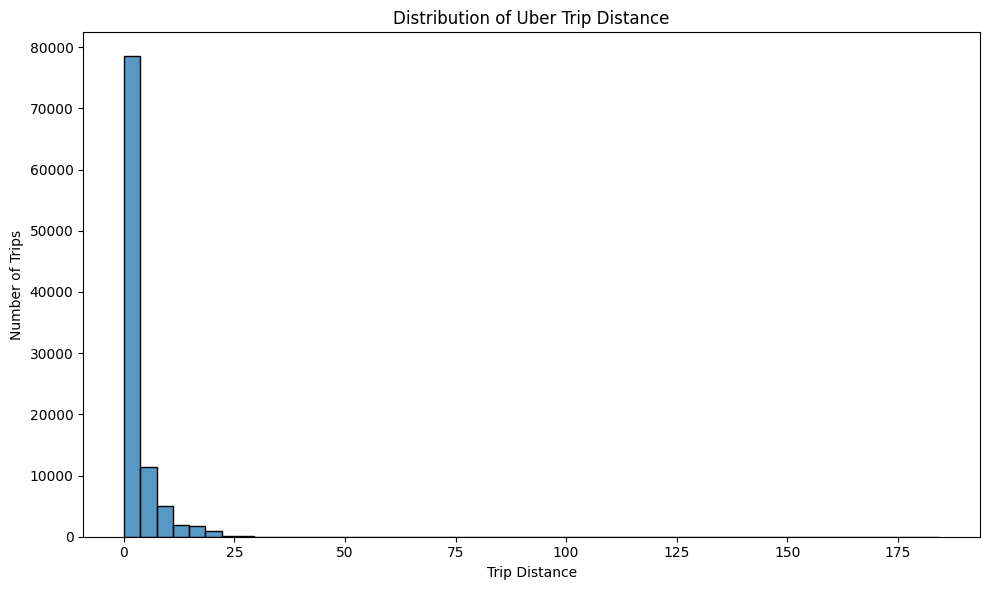

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="trip_distance",
    bins=50
)

plt.title("Distribution of Uber Trip Distance")
plt.xlabel("Trip Distance")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

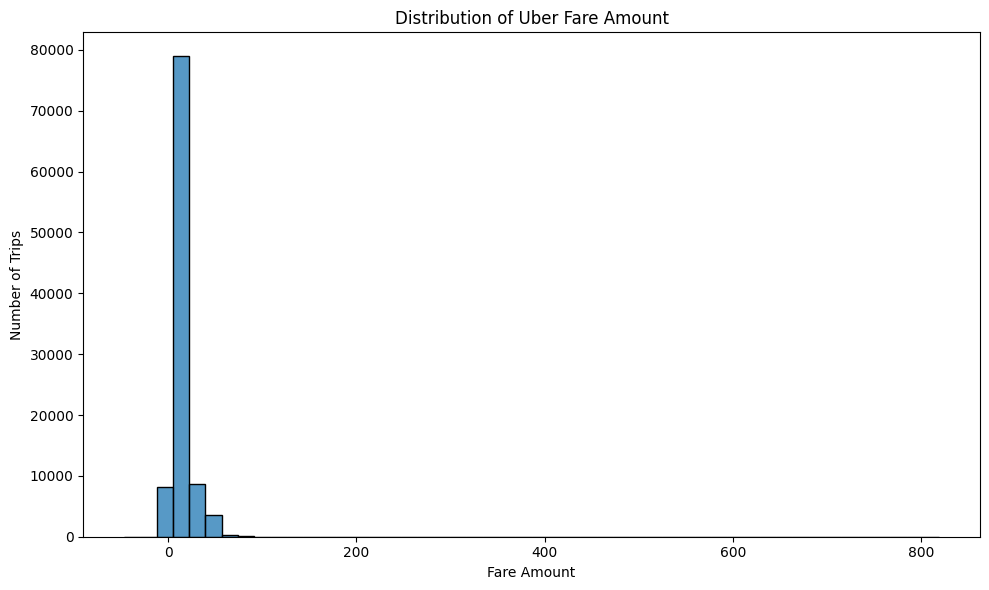

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="fare_amount",
    bins=50
)

plt.title("Distribution of Uber Fare Amount")
plt.xlabel("Fare Amount")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

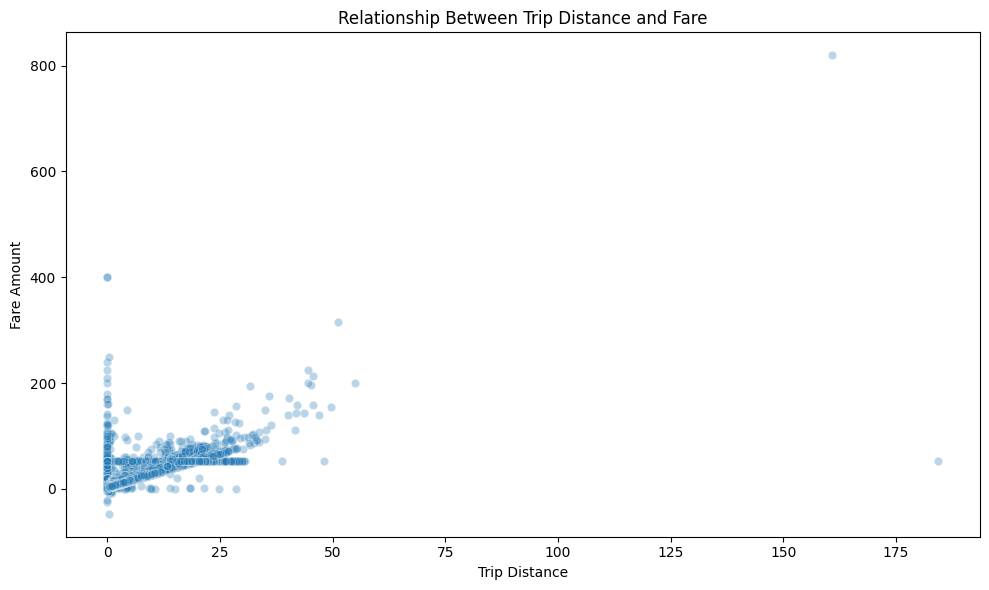

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="trip_distance",
    y="fare_amount",
    alpha=0.3
)

plt.title("Relationship Between Trip Distance and Fare")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.tight_layout()
plt.show()

## 7. Initial Data Observations

The dataset has been examined using descriptive statistics and visualizations. The distributions of trip distance and fare amount provide insights into the range and spread of the observed values.

The scatter plot helps examine the relationship between trip distance and fare. These observations guide the data cleaning and preprocessing steps required before training the regression models.

Final observations about missing values, outliers, and variable relationships will be based on the actual outputs obtained from the dataset.

# 8. Data Preprocessing

Data preprocessing prepares the raw Uber trip dataset for machine learning. The pickup and drop-off timestamps are converted into datetime format, and trip duration is calculated in minutes.

Records with missing timestamps, non-positive trip durations, invalid distances, or unusable feature values are removed. Relevant trip characteristics are selected as input features, while the calculated trip duration is used as the target variable.

The dataset is then divided into training and testing sets. Numerical features are scaled for algorithms that are sensitive to feature magnitudes.

In [ ]:
# Work on a copy of the original dataset
data = df.copy()

# Convert timestamps into datetime values using the correct column names
data["tpep_pickup_datetime"] = pd.to_datetime(
    data["tpep_pickup_datetime"], errors="coerce"
)

data["tpep_dropoff_datetime"] = pd.to_datetime(
    data["tpep_dropoff_datetime"], errors="coerce"
)

# Convert relevant numeric columns
numeric_columns = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude"
]

for col in numeric_columns:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

# Calculate duration in minutes using corrected columns
data["trip_duration_minutes"] = (
    data["tpep_dropoff_datetime"] - data["tpep_pickup_datetime"]
).dt.total_seconds() / 60

print("Rows before cleaning:", len(data))

# Remove records with invalid timestamps or target values
data = data.dropna(
    subset=["tpep_pickup_datetime", "tpep_dropoff_datetime",
            "trip_duration_minutes", "trip_distance"]
)

# Retain positive trip durations and positive distances
data = data[
    (data["trip_duration_minutes"] > 0) &
    (data["trip_distance"] > 0)
].copy()

print("Rows after basic cleaning:", len(data))
print("Duration summary (minutes):")
display(data["trip_duration_minutes"].describe().round(2))

Rows before cleaning: 100000
Rows after basic cleaning: 99409
Duration summary (minutes):


,trip_duration_minutes
count,99409.00
mean,16.96
std,60.84
min,0.02
25%,6.80
50%,11.52
75%,18.72
max,1439.38


In [ ]:
# Inspect extreme values before filtering
print("Duration 99th percentile:",
      data["trip_duration_minutes"].quantile(0.99))

print("Distance 99th percentile:",
      data["trip_distance"].quantile(0.99))

# Remove extreme records using percentile-based thresholds
duration_limit = data["trip_duration_minutes"].quantile(0.99)
distance_limit = data["trip_distance"].quantile(0.99)

data = data[
    (data["trip_duration_minutes"] <= duration_limit) &
    (data["trip_distance"] <= distance_limit)
].copy()

print("\nRows after filtering extreme values:", len(data))
print("Maximum retained duration:",
      round(data["trip_duration_minutes"].max(), 2), "minutes")
print("Maximum retained distance:",
      round(data["trip_distance"].max(), 2))

Duration 99th percentile: 56.416666666666664
Distance 99th percentile: 18.72

Rows after filtering extreme values: 97672
Maximum retained duration: 56.42 minutes
Maximum retained distance: 18.72


## 9. Feature Selection

The input features are selected to represent information that could be available when a trip begins. These include trip distance, passenger count, pickup coordinates, drop-off coordinates, and pickup time characteristics.

The drop-off timestamp is excluded from the input features because it is used to calculate the target variable. Including it would introduce target leakage and would not represent a realistic prediction made at pickup time.

Fare-related variables are also excluded because the aim is to predict trip duration from trip characteristics rather than use information recorded after or during the completed trip.

In [ ]:
# Derive features from pickup time
data["pickup_hour"] = data["tpep_pickup_datetime"].dt.hour
data["pickup_day"] = data["tpep_pickup_datetime"].dt.day
data["pickup_month"] = data["tpep_pickup_datetime"].dt.month
data["pickup_weekday"] = data["tpep_pickup_datetime"].dt.dayofweek

# Select available features from the dataset
candidate_features = [
    "passenger_count",
    "trip_distance",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "pickup_hour",
    "pickup_day",
    "pickup_month",
    "pickup_weekday"
]

features = [col for col in candidate_features if col in data.columns]

# Input features and target
X = data[features].copy()
y = data["trip_duration_minutes"].copy()

# Handle missing or infinite feature values
X = X.replace([np.inf, -np.inf], np.nan)

valid_rows = X.notna().all(axis=1) & y.notna()
X = X.loc[valid_rows]
y = y.loc[valid_rows]

print("Selected features:", features)
print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget variable: trip_duration_minutes")

Selected features: ['passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_weekday']
Input shape: (97672, 10)
Target shape: (97672,)

Target variable: trip_duration_minutes


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Number of input features:", X_train.shape[1])

Training samples: 78137
Testing samples: 19535
Number of input features: 10


In [ ]:
scaler = StandardScaler()

# Fit only on training features to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test features using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Feature scaling completed.
Scaled training shape: (78137, 10)
Scaled testing shape: (19535, 10)


## 10. Preprocessing Summary

The pickup and drop-off timestamps were converted into datetime format, and trip duration was calculated in minutes. Invalid records and extreme values were filtered according to the selected cleaning rules.

Pickup time characteristics and relevant trip features were selected as model inputs. Variables that could reveal the completed trip outcome were excluded to reduce data leakage.

The cleaned dataset was divided into training and testing sets, and numerical features were standardized where appropriate. The prepared data is now ready for regression model training.

# 11. Model Building

According to Unit 2 — Supervised Learning, this case study applies regression techniques to predict Uber trip duration.

The following five regression algorithms are implemented:

1. **Linear Regression:** Models the relationship between input variables and trip duration using a linear function. The least-squares method minimizes the sum of squared residuals.
2. **K-Nearest Neighbors (KNN) Regression:** Predicts trip duration using the target values of nearby training samples.
3. **Decision Tree Regression:** Predicts numerical values by splitting observations according to feature-based decision rules.
4. **Random Forest Regression:** Combines predictions from multiple decision trees to improve predictive performance.
5. **Support Vector Regression (SVR):** Uses Support Vector Machine principles to estimate continuous numerical values while controlling prediction error.

All five algorithms are trained on the same training dataset and evaluated on the same test dataset.

In [ ]:
from sklearn.svm import SVR

In [ ]:
# Store trained models and predictions
models = {}
predictions = {}

# 1. Linear Regression
print("Training Linear Regression...")

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

models["Linear Regression"] = lr
predictions["Linear Regression"] = lr.predict(X_test_scaled)


# 2. K-Nearest Neighbors Regression
print("Training KNN Regression...")

knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_scaled, y_train)

models["KNN Regression"] = knn
predictions["KNN Regression"] = knn.predict(X_test_scaled)


# 3. Decision Tree Regression
print("Training Decision Tree Regression...")

dt = DecisionTreeRegressor(
    max_depth=15,
    random_state=42
)
dt.fit(X_train, y_train)

models["Decision Tree"] = dt
predictions["Decision Tree"] = dt.predict(X_test)


# 4. Random Forest Regression
print("Training Random Forest Regression...")

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

models["Random Forest"] = rf
predictions["Random Forest"] = rf.predict(X_test)


# 5. Support Vector Regression
print("Training Support Vector Regression...")

svr = SVR(kernel="rbf", C=1.0, epsilon=0.1)
svr.fit(X_train_scaled, y_train)

models["Support Vector Regression"] = svr
predictions["Support Vector Regression"] = svr.predict(X_test_scaled)

print("\nAll five regression models trained successfully!")

Training Linear Regression...
Training KNN Regression...
Training Decision Tree Regression...
Training Random Forest Regression...
Training Support Vector Regression...

All five regression models trained successfully!


## 12. Model Evaluation Metrics

The five regression models are evaluated using the following metrics:

- **Mean Absolute Error (MAE):** Measures the average absolute difference between actual and predicted trip durations.
- **Mean Squared Error (MSE):** Measures the average squared prediction error.
- **Root Mean Squared Error (RMSE):** Represents the square root of MSE and expresses prediction error in minutes.
- **R² Score:** Measures how well the model explains the variation in trip duration compared with a mean-prediction baseline.

Lower MAE, MSE, and RMSE values generally indicate smaller prediction errors. A higher R² score generally indicates better predictive performance.

In [ ]:
results = []

for name, y_pred in predictions.items():
    mse = mean_squared_error(y_test, y_pred)

    results.append({
        "Algorithm": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2 Score": r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

display(results_df.round(4))

,Algorithm,MAE,MSE,RMSE,R2 Score
0,Random Forest,2.5250,13.3795,3.6578,0.8538
1,Decision Tree,2.9778,19.1817,4.3797,0.7904
2,KNN Regression,3.3608,23.1468,4.8111,0.7470
3,Support Vector Regression,3.3527,23.6412,4.8622,0.7416
4,Linear Regression,4.2294,32.8323,5.7300,0.6412


In [ ]:
best_row = results_df.iloc[0]

print("BEST-PERFORMING REGRESSION MODEL")
print("-" * 45)
print("Algorithm:", best_row["Algorithm"])
print(f"MAE:      {best_row['MAE']:.4f} minutes")
print(f"MSE:      {best_row['MSE']:.4f}")
print(f"RMSE:     {best_row['RMSE']:.4f} minutes")
print(f"R² Score: {best_row['R2 Score']:.4f}")

BEST-PERFORMING REGRESSION MODEL
---------------------------------------------
Algorithm: Random Forest
MAE:      2.5250 minutes
MSE:      13.3795
RMSE:     3.6578 minutes
R² Score: 0.8538


# 13. Model Performance Visualization

Visualizations are used to compare the predictive performance of the five regression algorithms. The models are evaluated using MAE, RMSE, and R² score.

The comparison graphs help identify models with lower prediction errors and better explanatory performance. An actual-versus-predicted plot is also used to examine how closely each model's predictions match the observed trip durations.

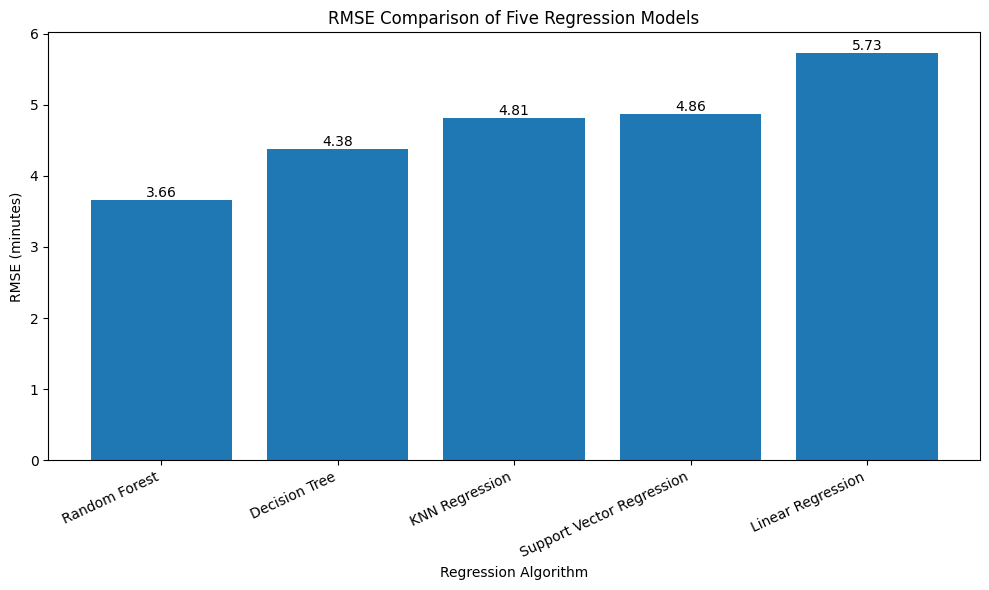

In [ ]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    results_df["Algorithm"],
    results_df["RMSE"]
)

plt.title("RMSE Comparison of Five Regression Models")
plt.xlabel("Regression Algorithm")
plt.ylabel("RMSE (minutes)")
plt.xticks(rotation=25, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

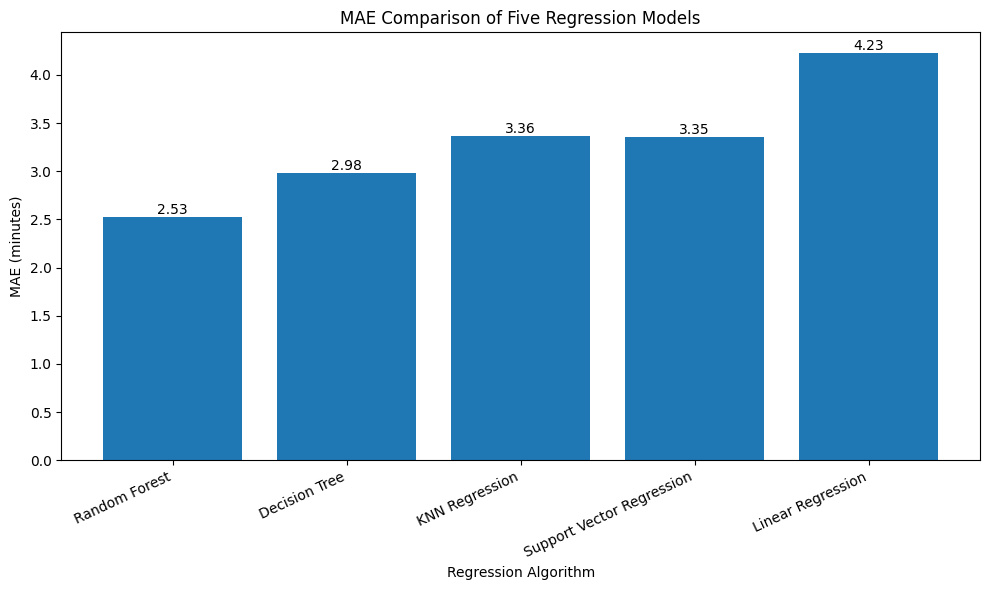

In [ ]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    results_df["Algorithm"],
    results_df["MAE"]
)

plt.title("MAE Comparison of Five Regression Models")
plt.xlabel("Regression Algorithm")
plt.ylabel("MAE (minutes)")
plt.xticks(rotation=25, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

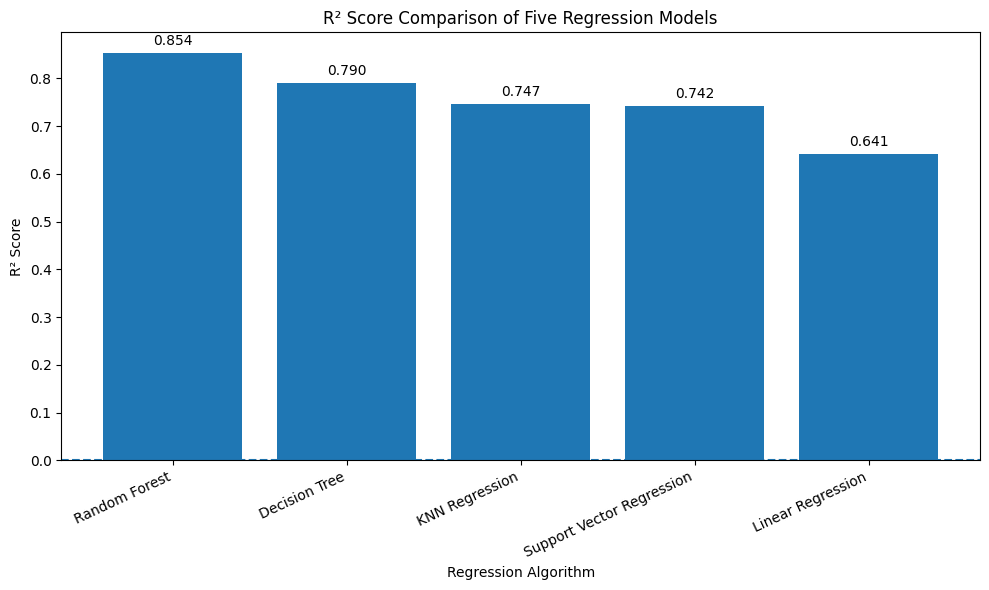

In [ ]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    results_df["Algorithm"],
    results_df["R2 Score"]
)

plt.title("R² Score Comparison of Five Regression Models")
plt.xlabel("Regression Algorithm")
plt.ylabel("R² Score")
plt.xticks(rotation=25, ha="right")
plt.axhline(y=0, linestyle="--")

for bar in bars:
    height = bar.get_height()
    offset = 0.01 if height >= 0 else -0.03

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + offset,
        f"{height:.3f}",
        ha="center",
        va="bottom" if height >= 0 else "top"
    )

plt.tight_layout()
plt.show()

## 14. Actual-versus-Predicted Analysis

Actual-versus-predicted plots compare the observed trip durations with the durations estimated by each regression model.

If predictions are accurate, the points should lie close to the diagonal reference line. Larger deviations from the line indicate larger prediction errors.

To keep the visualizations readable, a random sample of test observations is displayed for each model.

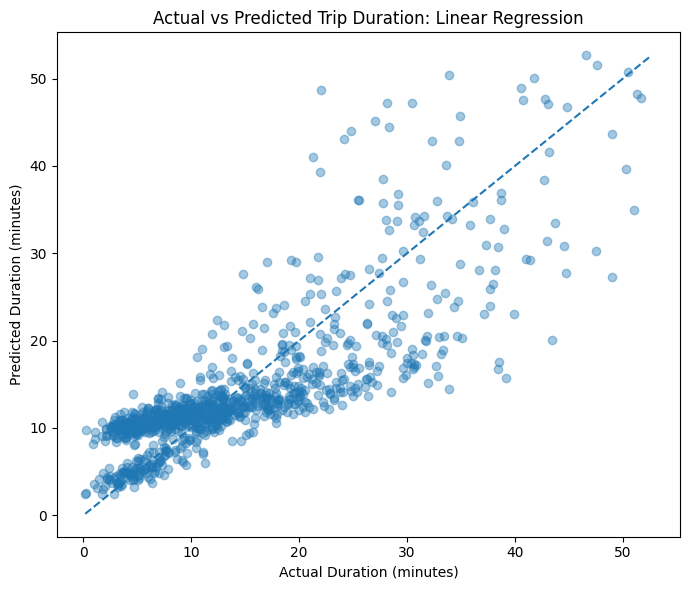

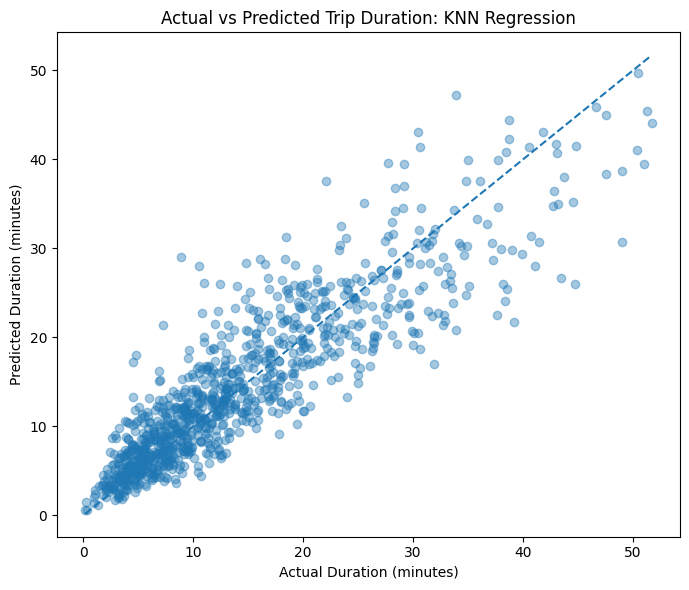

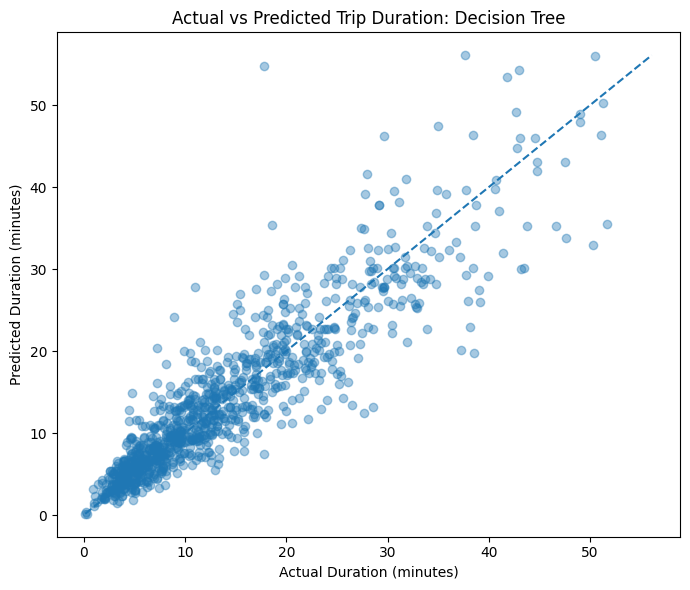

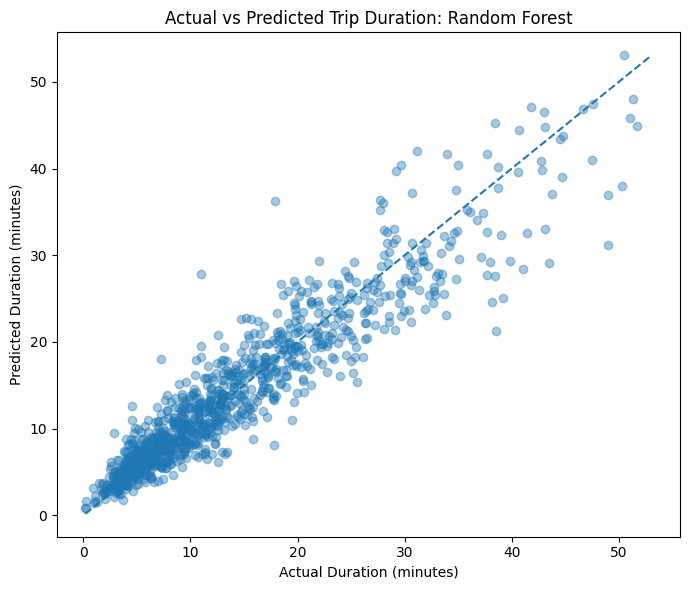

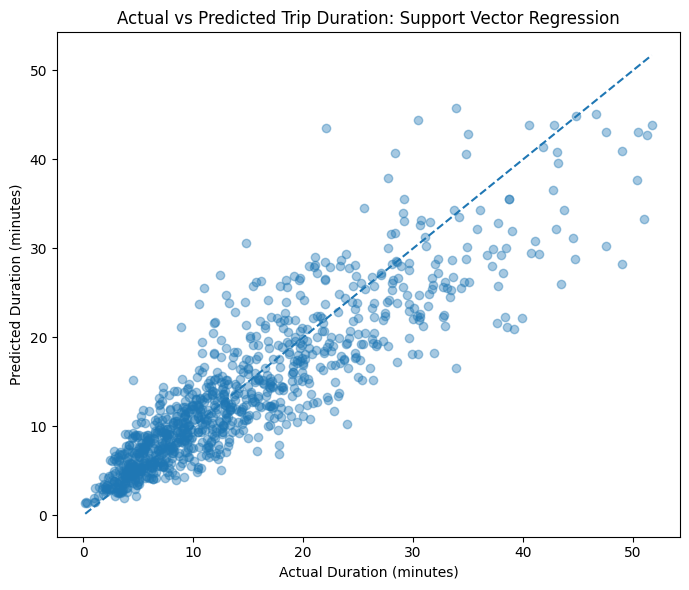

In [ ]:
# Select up to 1000 test observations for plotting
rng = np.random.default_rng(42)

sample_size = min(1000, len(y_test))
sample_indices = rng.choice(
    len(y_test),
    size=sample_size,
    replace=False
)

actual_sample = np.asarray(y_test)[sample_indices]

for name, y_pred in predictions.items():
    predicted_sample = np.asarray(y_pred)[sample_indices]

    plt.figure(figsize=(7, 6))

    plt.scatter(
        actual_sample,
        predicted_sample,
        alpha=0.4
    )

    lower = min(actual_sample.min(), predicted_sample.min())
    upper = max(actual_sample.max(), predicted_sample.max())

    plt.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--"
    )

    plt.title(f"Actual vs Predicted Trip Duration: {name}")
    plt.xlabel("Actual Duration (minutes)")
    plt.ylabel("Predicted Duration (minutes)")
    plt.tight_layout()
    plt.show()

# 15. Results and Discussion

Five regression algorithms were trained and evaluated to predict Uber trip duration in minutes: Linear Regression, K-Nearest Neighbors Regression, Decision Tree Regression, Random Forest Regression, and Support Vector Regression.

The models were compared using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score. The error metrics indicate the magnitude of prediction errors, while R² measures model performance relative to a mean-prediction baseline.

The comparison table and graphs are used to identify the model with the lowest RMSE and examine whether it also performs well on the other evaluation metrics.

In [ ]:
# Display the final comparison table
print("FINAL REGRESSION MODEL COMPARISON")

display(results_df.round(4))

# Identify the model with the lowest RMSE
best_row = results_df.loc[results_df["RMSE"].idxmin()]

print("\nBest model based on RMSE:", best_row["Algorithm"])
print(f"MAE:      {best_row['MAE']:.4f} minutes")
print(f"MSE:      {best_row['MSE']:.4f}")
print(f"RMSE:     {best_row['RMSE']:.4f} minutes")
print(f"R² Score: {best_row['R2 Score']:.4f}")

FINAL REGRESSION MODEL COMPARISON


,Algorithm,MAE,MSE,RMSE,R2 Score
0,Random Forest,2.5250,13.3795,3.6578,0.8538
1,Decision Tree,2.9778,19.1817,4.3797,0.7904
2,KNN Regression,3.3608,23.1468,4.8111,0.7470
3,Support Vector Regression,3.3527,23.6412,4.8622,0.7416
4,Linear Regression,4.2294,32.8323,5.7300,0.6412



Best model based on RMSE: Random Forest
MAE:      2.5250 minutes
MSE:      13.3795
RMSE:     3.6578 minutes
R² Score: 0.8538


## 16. Best-Performing Model

The model with the lowest Root Mean Squared Error (RMSE) is selected as the best-performing regression algorithm in this experiment.

Its MAE, MSE, RMSE, and R² score are examined to understand its prediction accuracy and overall performance. The final selection is based on the measured results obtained from the test dataset.

In [ ]:
best_row = results_df.loc[results_df["RMSE"].idxmin()]

print("=" * 55)
print("BEST-PERFORMING REGRESSION MODEL")
print("=" * 55)
print("Algorithm:", best_row["Algorithm"])
print(f"MAE:      {best_row['MAE']:.4f} minutes")
print(f"RMSE:     {best_row['RMSE']:.4f} minutes")
print(f"R² Score: {best_row['R2 Score']:.4f}")

BEST-PERFORMING REGRESSION MODEL
Algorithm: Random Forest
MAE:      2.5250 minutes
RMSE:     3.6578 minutes
R² Score: 0.8538


## 17. Limitations

- The dataset may contain inaccurate timestamps, unusual trips, and measurement errors.
- Filtering extreme values may remove some legitimate trips.
- Trip duration depends on factors such as traffic, weather, road conditions, and route selection, which may not be represented in the selected features.
- Model performance depends on feature selection and hyperparameter settings.
- The results reflect the selected dataset, preprocessing steps, and train-test split.

Future improvements could include feature engineering, hyperparameter tuning, and incorporating additional information about traffic and road conditions.

# 18. Conclusion

This case study applied five supervised machine learning regression algorithms to predict Uber trip duration in minutes.

The dataset was explored, cleaned, and preprocessed before training Linear Regression, K-Nearest Neighbors Regression, Decision Tree Regression, Random Forest Regression, and Support Vector Regression models.

The models were evaluated using MAE, MSE, RMSE, and R² score. Comparison tables and visualizations were used to assess their predictive performance.

The algorithm with the lowest RMSE was selected as the best-performing model among the five tested. This case study demonstrates the application of supervised regression techniques to trip duration prediction and highlights the importance of data preprocessing, evaluation metrics, and model comparison.